# Probability Distributions for ML

## 📚 Learning Objectives

By completing this notebook, you will:
- Work with common probability distributions
- Sample, fit, and visualize distributions
- Connect distributions to ML (e.g. likelihood)

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 01 "03. Learning under Uncertainty" — you met distributions there as a tool for reasoning; here they become objects you fit to data.

**Used later in:** Course 10 (AIAT 124) — Unit 1, lesson 03 "Probabilistic Generative Models" — a generative model *is* a distribution you sample from.

---


---

## 📌 Real case: $4.6 billion lost to an assumption about the tails

Long-Term Capital Management was a hedge fund whose partners included **Myron Scholes and Robert Merton,
who had shared the 1997 Nobel Prize in Economics**. Its risk models were state of the art. In 1998, over
less than four months, it lost **$4.6 billion**, and on 23 September fourteen financial institutions
assembled a **$3.6 billion** recapitalisation to stop the collapse from spreading.

The technical cause is a distribution. Their value-at-risk models were fitted to five years of data and
assumed returns behaved like a well-known bell-shaped curve. As the historian Niall Ferguson put it, those
models "implied that the loss Long Term suffered in August was so unlikely that it ought never to have
happened in the entire life of the universe." The market did it anyway, because real financial returns
have far heavier tails than a normal distribution allows, and five years of calm data contains no evidence
of that.

**What goes wrong without this.** A distribution is a claim about what is *possible*, not just about what
is typical — and the far tail of the curve you chose is where your worst day lives. The cell below fits a
normal curve to real Titanic fares and prints the consequence: that fitted normal places **26% of its
probability below zero**, i.e. it expects a quarter of passengers to have been paid to board. The model
does not complain. It just assigns a comfortable probability to something impossible.


# Probability Distributions for ML

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Basic statistics**: Mean, variance, standard deviation
- ✅ **Basic understanding**: What is probability?

**If you haven't completed these**, you might struggle with:
- Understanding probability distributions
- Understanding normal distribution
- Using distributions in ML

---

## 🔗 Where This Notebook Fits

**This is the FIRST example of Module 05** - foundation of statistical inference!

**Why this example FIRST?**
- **Before** you can do statistical inference, you need probability distributions
- **Before** you can test hypotheses, you need distributions
- **Before** you can quantify uncertainty, you need distributions

**Builds on**: Basic statistics

**Leads to**: Example 2: Statistical Inference, Example 3: Bayesian Inference

---

## The Story: Understanding Before Using

Imagine predicting weather. **Before** you can predict, you need to understand probability distributions of weather patterns. **After** understanding distributions, you can make probabilistic predictions!

Same with machine learning: **Before** quantifying uncertainty, we need probability distributions. **After** understanding them, we can make confident predictions with uncertainty estimates!

---

## Why This Concept Matters

### Why Probability Distributions Matter in ML

**WHY** are distributions essential?

1. **Uncertainty Quantification**:
   - **WHY**: Need to quantify prediction uncertainty
   - **HOW**: Use probability distributions
   - **AFTER**: Can provide confidence intervals

2. **Model Assumptions**:
   - **WHY**: Many models assume distributions
   - **HOW**: Understand which distribution fits data
   - **AFTER**: Better model selection

3. **Statistical Inference**:
   - **WHY**: Need distributions for hypothesis testing
   - **HOW**: Use distributions to test hypotheses
   - **AFTER**: Can make statistical conclusions

**Common Student Questions:**
- **Q: What is a probability distribution?**
  - Answer: Distribution = describes how likely different values are
  - Example: Normal distribution = bell curve (most values near mean, fewer at extremes)
  - Tells us: Probability of each possible value
  - In ML: Used to model uncertainty, make probabilistic predictions
- **Q: Why is normal distribution so common?**
  - Answer: Many natural phenomena follow normal distribution (Central Limit Theorem)
  - Example: Heights, test scores, measurement errors → all approximately normal
  - Why: Sum of many random variables → tends toward normal
  - In ML: Many models assume normal distribution (simplifies math)
- **Q: What is mean and standard deviation?**
  - Answer: Mean (μ) = center of distribution (average), Std (σ) = spread (how wide)
  - Normal distribution: N(μ, σ²) = mean μ, variance σ²
  - Mean = 0, Std = 1 → standard normal distribution
  - 68% of values within 1 std, 95% within 2 std, 99.7% within 3 std
- **Q: Why do we need distributions in ML?**
  - Answer: ML predictions have uncertainty → distributions quantify uncertainty
  - Example: Predict price = $100,000 ± $10,000 (with 95% confidence)
  - Without distributions: Only point predictions (no uncertainty)
  - With distributions: Probabilistic predictions (with confidence intervals)
- **Q: What's the difference between probability and statistics?**
  - Answer: Probability = forward (given distribution, what's probability of outcome?)
  - Statistics = backward (given data, what distribution generated it?)
  - Example: Probability = "If coin is fair, P(heads) = 0.5"
  - Example: Statistics = "I see 60 heads in 100 flips → is coin fair?"
  - In ML: Use both (probability for predictions, statistics for inference)

## Learning Objectives
1. Understand probability distributions
2. Understand normal distribution
3. Generate and visualize distributions
4. Apply to ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy/Matplotlib for the maths and plots, scipy.stats for the normality check,
# the shared data loader for the Titanic file, and sklearn for the real medical measurements.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_breast_cancer

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("crime_statistics_original_50"), ...
# -------------------------------------------------------------------------------------


print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this works in ML!

## Step 2: Implementation

**BEFORE**: We understand the concept.

**AFTER**: We'll see HOW it's implemented!

In [2]:
# Example 1: Probability Distributions on REAL measurements
# WHY: Need to quantify uncertainty in quantities we actually observe
# HOW: Fit a probability distribution to real data and check whether it fits

# Real measurement: "mean texture" from 569 breast-tumour biopsies - the standard
# deviation of grey-scale values in the digitised image of each tumour.
cancer = load_breast_cancer()
samples = cancer.data[:, list(cancer.feature_names).index("mean texture")]
variable_name = "mean texture (breast-tumour biopsies)"

# Fit a normal distribution to it: the fitted mean and std ARE the maximum-likelihood
# estimates (you will derive that in notebook 06).
mean = samples.mean()
std = samples.std(ddof=0)

print("Example 1: Probability Distributions")
print("=" * 60)
print(f"Real variable: {variable_name}, n = {len(samples)}")
print(f"Fitted normal distribution: mean={mean:.4f}, std={std:.4f}")
print(f"Sample mean: {np.mean(samples):.4f}")
print(f"Sample std: {np.std(samples):.4f}")
print(f"Skewness: {stats.skew(samples):.4f}  (0 would be perfectly symmetric)")

# Is it really normal? Ask a test rather than eyeballing it.
shapiro_p = stats.shapiro(samples).pvalue
print(f"\nShapiro-Wilk normality test: p = {shapiro_p:.2e}")
print("The bell shape is a good working model, but with 569 real measurements the test")
print("still detects a mild right skew - real data is never EXACTLY normal.")

# A real variable that is not remotely normal, for contrast: Titanic ticket fares.
titanic = load("titanic")
fares = titanic["Fare"].dropna().to_numpy()
print(f"\nContrast - Titanic ticket fares (n = {len(fares)}): "
      f"skewness = {stats.skew(fares):.2f}")
print("Heavily right-skewed: a handful of first-class fares stretch the tail far out.")
print("Assuming normality here would be a modelling mistake, not a rounding error.")

print(f"\n💡 WHY: Quantifies uncertainty in predictions")
print(f"💡 HOW: Fit a distribution to real data - then CHECK the fit")
print(f"💡 AFTER: Can provide confidence intervals - when the assumption holds!")


Example 1: Probability Distributions
Real variable: mean texture (breast-tumour biopsies), n = 569
Fitted normal distribution: mean=19.2896, std=4.2973
Sample mean: 19.2896
Sample std: 4.2973
Skewness: 0.6487  (0 would be perfectly symmetric)

Shapiro-Wilk normality test: p = 7.28e-08
The bell shape is a good working model, but with 569 real measurements the test
still detects a mild right skew - real data is never EXACTLY normal.
titanic: full file, 891 rows.

Contrast - Titanic ticket fares (n = 891): skewness = 4.78
Heavily right-skewed: a handful of first-class fares stretch the tail far out.
Assuming normality here would be a modelling mistake, not a rounding error.

💡 WHY: Quantifies uncertainty in predictions
💡 HOW: Fit a distribution to real data - then CHECK the fit
💡 AFTER: Can provide confidence intervals - when the assumption holds!


---

## 📊 Visualization

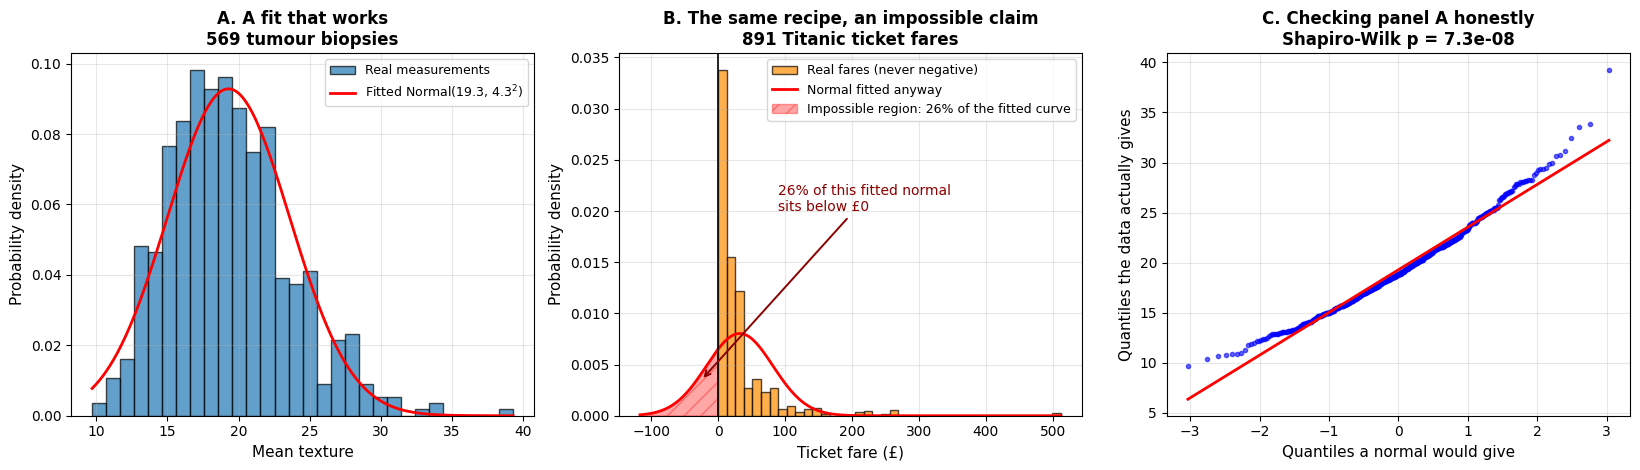


📊 Read the figure:
  A - the blue histogram and the red curve track each other: the normal is a
      reasonable working model for tumour texture.
  B - the hatched red wedge left of the black £0 line is 26% of the fitted
      normal's probability. It says a quarter of passengers were PAID to board.
      The fitting code never complains; only the picture does.
  C - the same data as A, plotted against what a perfect normal would give.
      The points hug the red line in the middle and lie ABOVE it at BOTH ends:
      the upper tail runs further than a normal predicts and the lower tail stops
      short. That asymmetry IS the mild right skew (skewness 0.65) that Shapiro-Wilk reports as p = 7.3e-08.
  Lesson: plot the data, and plot the model OUTSIDE the range the data occupies.


In [3]:
# ONE figure carrying the whole lesson: a fitted distribution is a claim about what is
# POSSIBLE, not only about what is typical.
# WHY three panels: (A) a fit that works, (B) the same recipe making an impossible claim,
# (C) how you check a fit properly instead of trusting the eye.

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

# --- Panel A: real tumour textures + the normal curve fitted to them -------------------
axes[0].hist(samples, bins=30, density=True, alpha=0.7, edgecolor='black',
             label='Real measurements')
x_range = np.linspace(samples.min(), samples.max(), 200)
y_range = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mean) / std) ** 2)
axes[0].plot(x_range, y_range, 'r-', linewidth=2,
             label=f'Fitted Normal({mean:.1f}, {std:.1f}$^2$)')
axes[0].set_xlabel('Mean texture', fontsize=11)
axes[0].set_ylabel('Probability density', fontsize=11)
axes[0].set_title('A. A fit that works\n569 tumour biopsies', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Panel B: real fares + the badly fitting normal, INCLUDING the impossible region ----
# WHY plot below zero: the mistake is invisible if we only draw the range the data occupies.
fare_mu, fare_sd = fares.mean(), fares.std()
p_negative = stats.norm.cdf(0, fare_mu, fare_sd)

axes[1].hist(fares, bins=40, density=True, alpha=0.7, color='darkorange',
             edgecolor='black', label='Real fares (never negative)')
xf = np.linspace(fare_mu - 3 * fare_sd, fares.max(), 400)
axes[1].plot(xf, stats.norm.pdf(xf, fare_mu, fare_sd), 'r-', linewidth=2,
             label='Normal fitted anyway')
x_bad = xf[xf < 0]
axes[1].fill_between(x_bad, 0, stats.norm.pdf(x_bad, fare_mu, fare_sd),
                     color='red', alpha=0.35, hatch='//', edgecolor='red',
                     label=f'Impossible region: {p_negative:.0%} of the fitted curve')
axes[1].axvline(0, color='black', linewidth=1.2)
axes[1].annotate(f'{p_negative:.0%} of this fitted normal\nsits below £0',
                 xy=(-25, 0.0035), xytext=(90, 0.020), fontsize=10, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred', linewidth=1.4))
axes[1].set_xlabel('Ticket fare (£)', fontsize=11)
axes[1].set_ylabel('Probability density', fontsize=11)
axes[1].set_title('B. The same recipe, an impossible claim\n891 Titanic ticket fares',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# --- Panel C: how to CHECK a fit - quantiles of the data against normal quantiles -------
# WHY: panel A looks convincing to the eye, yet Shapiro-Wilk rejects normality. A Q-Q plot
# shows WHERE the disagreement is: on the straight line = agrees, bending away = does not.
stats.probplot(samples, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_markersize(3)
axes[2].get_lines()[0].set_alpha(0.6)
axes[2].get_lines()[1].set_color('red')
axes[2].get_lines()[1].set_linewidth(2)
axes[2].set_title(f'C. Checking panel A honestly\nShapiro-Wilk p = {shapiro_p:.1e}',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Quantiles a normal would give', fontsize=11)
axes[2].set_ylabel('Quantiles the data actually gives', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Read the figure:")
print("  A - the blue histogram and the red curve track each other: the normal is a")
print("      reasonable working model for tumour texture.")
print(f"  B - the hatched red wedge left of the black £0 line is {p_negative:.0%} of the fitted")
print("      normal's probability. It says a quarter of passengers were PAID to board.")
print("      The fitting code never complains; only the picture does.")
print("  C - the same data as A, plotted against what a perfect normal would give.")
print("      The points hug the red line in the middle and lie ABOVE it at BOTH ends:")
print("      the upper tail runs further than a normal predicts and the lower tail stops")
print("      short. That asymmetry IS the mild right skew (skewness "
      f"{stats.skew(samples):.2f}) that Shapiro-Wilk reports as p = {shapiro_p:.1e}.")
print("  Lesson: plot the data, and plot the model OUTSIDE the range the data occupies.")


**📖 What to see in the figure above.** Panel A is the picture people stop at: a bell that
matches its histogram. Panel B is the same procedure applied to fares, drawn *past the edge of
the data* — the hatched wedge to the left of the black £0 line is real probability that the
fitted model assigns to an impossible event. Panel C is the check you should run on panel A:
on a Q-Q plot, agreement with the normal is a straight line, and here the points sit above the
line at **both** ends — a long upper tail and a short lower one, which is exactly what a right
skew looks like and what the Shapiro–Wilk test picks up. A distribution you never plotted
outside the observed range is an assumption you never tested.

---

## ⚠️ Where this breaks

- **"Looks normal" is not a test, and the test here fails.** The tumour-texture measurements produce a
  handsome bell-shaped histogram, and the Shapiro–Wilk test on the same 569 numbers returns
  **p = 7.28 × 10⁻⁸** — decisive evidence they are *not* normal, driven by a skewness of 0.6487. The normal
  is a good working model here, and it is not the truth. Both statements are needed.
- **A distribution fitted to a bounded quantity will put mass outside the bounds.** Fares cannot be
  negative; the fitted normal says 26% of them are. Ages cannot be negative, counts cannot be fractional,
  probabilities cannot exceed 1 (Notebook 00 of this unit prints a confidence interval that does). Before
  fitting, ask what values the quantity can physically take, and choose a family that respects them —
  log-normal or gamma for positive skewed quantities, Poisson or negative binomial for counts, Beta for
  proportions.
- **Sample size decides what "non-normal" means.** With n = 569 the Shapiro–Wilk test detects a mild skew
  that would not affect any decision you make. With n = 30 it would fail to detect a skew that matters.
  A normality test answers "is there evidence of departure", not "is the departure large enough to care
  about" — for that, look at the plot and the skewness, as the notebook does.
- **Cheaper alternative.** If you only need a middle and a spread, the median and the interquartile range
  need no distributional assumption at all, and they survive the fare data unharmed.


---

## 💬 Discuss

1. LTCM's models were built by Nobel laureates on five years of real data. What could have been done
   differently that was actually available to them in 1998 — and what does your answer imply about the
   models you will build with three years of company data?
2. Shapiro–Wilk rejects normality for the tumour textures (p = 7.28 × 10⁻⁸), yet the notebook goes on
   using a normal model. Is that dishonest, pragmatic, or both? State the condition under which you would
   stop using it.
3. A fitted normal places 26% of Titanic fare probability below zero. Suppose that model were being used to
   set an insurance premium. Describe concretely who would be overcharged and who undercharged, and how you
   would notice.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding probability distributions:

1. **Uncertainty Quantification**: Can quantify prediction uncertainty
2. **Statistical Inference**: Can test hypotheses
3. **Next Steps**: Learn statistical inference (Example 2) and Bayesian inference (Example 3)

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand this concept.

**AFTER this notebook**: We understand WHY, HOW, and AFTER!

---

## ✅ Example Complete!

## 📚 References

1. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Ch. 2: Probability Distributions. Springer.
2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 3: Probability and Information Theory. MIT Press. <https://www.deeplearningbook.org/>
3. Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/book1.html>
4. Nguyen, M. N., Baker, A., Neo, C., Roush, A., Kirsch, A., & Shwartz-Ziv, R. (2024). *Turning Up the Heat: Min-p Sampling for Creative and Coherent LLM Outputs*. arXiv. <https://arxiv.org/abs/2407.01082> — sampling from a categorical distribution, in the place students meet it most often: text decoding.
5. Liu, X., Chen, T., Da, L., Chen, C., Lin, Z., & Wei, H. (2025). *Uncertainty Quantification and Confidence Calibration in Large Language Models: A Survey*. arXiv. <https://arxiv.org/abs/2503.15850> — decoding stochasticity as one named source of uncertainty among several.
